# Cold-Start Sync & Reference Audio Generation

In [ ]:
# === CELL 1: COLAB COLD-START SYNC (MILESTONE 2) ===
import os
import wave
import numpy as np

for folder in ["src", "models", "assets", "output", "tests"]:
    os.makedirs(folder, exist_ok=True)

!pip install -q librosa scikit-learn joblib moviepy pytest numpy scipy soundfile

sample_wav = "assets/reference_120bpm.wav"
if not os.path.exists(sample_wav):
    sr = 22050
    duration_sec = 10.0
    t = np.linspace(0, duration_sec, int(sr * duration_sec), endpoint=False)
    # Add subtle background noise to prevent zero-division in MFCC extraction
    signal = 0.015 * np.random.default_rng(42).standard_normal(len(t))

    # Generate 120 BPM beats (every 0.5 seconds)
    for beat_time in np.arange(0.5, duration_sec, 0.5):
        idx = int(beat_time * sr)
        burst_len = int(0.04 * sr)
        envelope = np.exp(-np.linspace(0, 8, burst_len))
        tone = np.sin(2 * np.pi * 110.0 * np.arange(burst_len) / sr)
        signal[idx : idx + burst_len] += 0.95 * envelope * tone

    pcm_data = np.int16(np.clip(signal, -1.0, 1.0) * 32767)
    with wave.open(sample_wav, "wb") as wf:
        wf.setnchannels(1)
        wf.setsampwidth(2)
        wf.setframerate(sr)
        wf.writeframes(pcm_data.tobytes())

print("[COLD-START READY] Workspace directories and 120 BPM reference audio initialized.")

[COLD-START READY] Workspace directories and 120 BPM reference audio initialized.


# Write src/ml_classifier.py

In [ ]:
%%writefile src/ml_classifier.py
"""
Milestone 2: STFT Musical Surface & MFCC Feature Extractor, SVM/kNN Classifier,
Model Serialization, and Pacing/Mode Router (Tasks T7-T10).
Author: Michael David Gonzales
Course: COS660 Capstone - Full Sail University
"""

import os
import time
from typing import Any, Dict, List, Tuple
import joblib
import librosa
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


class AudioClassifier:
    """
    Supervised Machine Learning Audio Beat Classifier & Mode Router (Tasks T7-T10).
    """

    def __init__(
        self,
        n_fft: int = 512,
        hop_length: int = 256,
        n_mfcc: int = 13,
        target_fps: float = 30.0,
        cooldown_sec: float = 0.25,
        model_path: str = "models/audio_classifier.pkl",
    ) -> None:
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.n_mfcc = n_mfcc
        self.target_fps = target_fps
        self.cooldown_sec = cooldown_sec
        self.model_path = model_path
        self.best_model: Any = None
        self.best_model_name: str = ""

    # Task T7: Extract 18-feature STFT Musical Surface + MFCC matrix
    def extract_stft_mfcc_features(self, audio_signal: np.ndarray, sample_rate: int) -> np.ndarray:
        stft_mag = np.abs(librosa.stft(audio_signal, n_fft=self.n_fft, hop_length=self.hop_length, center=False))
        n_frames = stft_mag.shape[1]

        flux = np.zeros(n_frames, dtype=np.float64)
        flux[1:] = np.sqrt(np.sum(np.diff(stft_mag, axis=1) ** 2, axis=0))
        centroid = librosa.feature.spectral_centroid(S=stft_mag, sr=sample_rate, n_fft=self.n_fft, hop_length=self.hop_length)[0, :n_frames]
        rolloff = librosa.feature.spectral_rolloff(S=stft_mag, sr=sample_rate, n_fft=self.n_fft, hop_length=self.hop_length)[0, :n_frames]
        zcr = librosa.feature.zero_crossing_rate(y=audio_signal, frame_length=self.n_fft, hop_length=self.hop_length, center=False)[0, :n_frames]
        rms = librosa.feature.rms(S=stft_mag, frame_length=self.n_fft, hop_length=self.hop_length)[0, :n_frames]
        mfccs = librosa.feature.mfcc(y=audio_signal, sr=sample_rate, n_mfcc=self.n_mfcc, n_fft=self.n_fft, hop_length=self.hop_length, center=False)[:, :n_frames]

        feature_matrix = np.vstack([flux, centroid, rolloff, zcr, rms, mfccs]).T
        return np.nan_to_num(feature_matrix, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float64)

    def generate_labeled_dataset(self, audio_signal: np.ndarray, sample_rate: int, beat_times_sec: List[float]) -> Tuple[np.ndarray, np.ndarray]:
        X = self.extract_stft_mfcc_features(audio_signal, sample_rate)
        frame_times = librosa.frames_to_time(np.arange(X.shape[0]), sr=sample_rate, hop_length=self.hop_length)
        y = np.zeros(X.shape[0], dtype=int)
        for bt in beat_times_sec:
            # Narrow the label window to only the closest frame
            idx = np.argmin(np.abs(frame_times - bt))
            y[idx] = 1
        return X, y

    # Task T8: Train & cross-validate SVM (Poly/RBF/Sigmoid) and kNN
    def train_and_evaluate_classifiers(self, X: np.ndarray, y: np.ndarray) -> Dict[str, Any]:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
        candidates = {
            "SVM_RBF": Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel="rbf", C=5.0, class_weight="balanced", random_state=42))]),
            "SVM_Poly": Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel="poly", degree=3, C=5.0, class_weight="balanced", random_state=42))]),
            "kNN_5": Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier(n_neighbors=3, weights="distance"))]),
        }

        cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
        benchmark_results, best_score = {}, -1.0

        for name, pipeline in candidates.items():
            cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="accuracy")
            pipeline.fit(X_train, y_train)
            raw_pred = pipeline.predict(X_test)

            # Apply NMS to predictions based on 250ms cooldown window
            y_pred = np.zeros_like(raw_pred)
            min_cooldown = max(1, int(round((self.cooldown_sec * 22050) / self.hop_length)))
            last_beat = -min_cooldown

            for idx, p in enumerate(raw_pred):
                if p == 1 and (idx - last_beat) >= min_cooldown:
                    # Find local peak in RMS energy (assuming RMS is column 4)
                    window_end = min(len(raw_pred), idx + 4)
                    local_peak = idx + int(np.argmax(X_test[idx:window_end, 4]))
                    y_pred[local_peak] = 1
                    last_beat = local_peak

            acc = float(accuracy_score(y_test, y_pred)) * 100.0
            prec = float(precision_score(y_test, y_pred, zero_division=0))
            rec = float(recall_score(y_test, y_pred, zero_division=0))

            benchmark_results[name] = {"cv_mean_acc": float(np.mean(cv_scores)) * 100.0, "test_acc": acc, "precision": prec, "recall": rec, "confusion_matrix": confusion_matrix(y_test, y_pred)}

            if (acc / 100.0) + prec + rec > best_score:
                best_score, self.best_model, self.best_model_name = (acc / 100.0) + prec + rec, pipeline, name

        winning = benchmark_results[self.best_model_name]
        return {"best_model_name": self.best_model_name, "AD_acc": winning["test_acc"], "precision": winning["precision"], "recall": winning["recall"], "confusion_matrix": winning["confusion_matrix"], "all_models": benchmark_results}

    # Task T9: Serialize best classifier & run inference
    # FIX: Added custom_path argument so the pytest suite can serialize to a temporary file
    def save_model(self, custom_path: str = "") -> str:
        target_path = custom_path or self.model_path
        os.makedirs(os.path.dirname(os.path.abspath(target_path)), exist_ok=True)
        joblib.dump(self.best_model, target_path)
        return os.path.abspath(target_path)

    def load_and_predict_timestamps(self, audio_signal: np.ndarray, sample_rate: int, custom_path: str = "") -> Tuple[List[float], float]:
        start_time = time.perf_counter()
        target_path = custom_path or self.model_path
        model = joblib.load(target_path)
        X = self.extract_stft_mfcc_features(audio_signal, sample_rate)
        predictions = model.predict(X)

        min_cooldown = max(1, int(round((self.cooldown_sec * sample_rate) / self.hop_length)))
        last_beat, beat_frames = -min_cooldown, []

        for idx, pred in enumerate(predictions):
            if pred == 1 and (idx - last_beat) >= min_cooldown:
                local_peak = idx + int(np.argmax(X[idx:min(len(predictions), idx + 4), 4])) # Refine with RMS energy
                beat_frames.append(local_peak)
                last_beat = local_peak

        raw_times = librosa.frames_to_time(beat_frames, sr=sample_rate, hop_length=self.hop_length)
        frame_step = 1.0 / self.target_fps
        snapped = []
        for t in raw_times:
            s = round(round(float(t) / frame_step) * frame_step, 4)
            if not snapped or s > snapped[-1]: snapped.append(s)

        return snapped, (time.perf_counter() - start_time) * 1000.0

    # Task T10: Mode Router
    @staticmethod
    def apply_pacing_filter(timestamps: List[float], speed_flag: str = "High") -> List[float]:
        return timestamps[::2] if speed_flag.strip().lower() == "low" else list(timestamps)

    @classmethod
    def route_engine_mode(cls, mode: str, h_ts: List[float], ai_ts: List[float], speed_flag: str = "High") -> Dict[str, List[float]]:
        h_f, ai_f = cls.apply_pacing_filter(h_ts, speed_flag), cls.apply_pacing_filter(ai_ts, speed_flag)
        if mode.lower() == "heuristic": return {"Heuristic": h_f}
        if mode.lower() == "ai_classifier": return {"AI_Classifier": ai_f}
        if mode.lower() == "ab_compare": return {"Sample_A_Heuristic": h_f, "Sample_B_AI_Classifier": ai_f}
        raise ValueError(f"[ERR_MODE_001] Invalid Mode: {mode}")

Overwriting src/ml_classifier.py


# Write Automated pytest V&V Suite

In [ ]:
%%writefile tests/test_milestone2.py
import os
import numpy as np
import pytest
from src.ml_classifier import AudioClassifier
import librosa

@pytest.fixture
def synthetic_audio():
    sr, duration = 22050, 10.0
    t = np.linspace(0, duration, int(sr * duration), endpoint=False)
    signal = 0.015 * np.random.default_rng(42).standard_normal(len(t))
    beat_times = list(np.arange(0.5, duration, 0.5))
    for bt in beat_times:
        idx, blen = int(bt * sr), int(0.04 * sr)
        signal[idx : idx + blen] += 0.95 * np.exp(-np.linspace(0, 8, blen)) * np.sin(2 * np.pi * 110.0 * np.arange(blen) / sr)
    return signal.astype(np.float32), sr, beat_times

def test_t7_extract_features(synthetic_audio):
    signal, sr, _ = synthetic_audio
    features = AudioClassifier().extract_stft_mfcc_features(signal, sr)
    assert features.shape[1] == 18
    assert not np.isnan(features).any()

def test_t8_svm_knn_training_metrics(synthetic_audio):
    signal, sr, beat_times = synthetic_audio
    clf = AudioClassifier()

    # Generate dataset and evaluate classifiers
    X, y = clf.generate_labeled_dataset(signal, sr, beat_times)
    metrics = clf.train_and_evaluate_classifiers(X, y)

    # Serialize a temporary model to test inference accuracy with tolerance
    clf.best_model.fit(X, y)
    clf.best_model_name = metrics["best_model_name"]
    clf.save_model("models/temp_test.pkl")

    test_clf = AudioClassifier(model_path="models/temp_test.pkl")
    predicted_ts, _ = test_clf.load_and_predict_timestamps(signal, sr)

    true_positives = 0
    tolerance = 0.025
    for pt in predicted_ts:
        if any(abs(pt - gt) <= tolerance for gt in beat_times):
            true_positives += 1

    precision = true_positives / len(predicted_ts) if predicted_ts else 0.0
    recall = true_positives / len(beat_times) if beat_times else 0.0

    assert metrics["AD_acc"] >= 76.6
    assert precision >= 0.80
    assert recall >= 0.80

def test_t9_serialize_and_inference(synthetic_audio, tmp_path):
    signal, sr, beat_times = synthetic_audio
    clf = AudioClassifier(model_path=str(tmp_path / "model.pkl"))

    X, y = clf.generate_labeled_dataset(signal, sr, beat_times)
    clf.train_and_evaluate_classifiers(X, y)

    assert os.path.isfile(clf.save_model())
    ts, ad_time = clf.load_and_predict_timestamps(signal, sr)
    assert ad_time < 2000.0

def test_t10_pacing_and_router():
    ts = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
    assert len(AudioClassifier.apply_pacing_filter(ts, "Low")) == 3
    routed = AudioClassifier.route_engine_mode("AB_Compare", ts, ts, "Low")
    assert "Sample_A_Heuristic" in routed and "Sample_B_AI_Classifier" in routed

Overwriting tests/test_milestone2.py


# EXECUTE V&V SUITE & PRINT TELEMETRY

In [ ]:
# === CELL 4: EXECUTE V&V SUITE & PRINT TELEMETRY ===
!python -m pytest tests/test_milestone2.py -v

import librosa
from src.ml_classifier import AudioClassifier

clf = AudioClassifier()
sig, sr = librosa.load("assets/reference_120bpm.wav", sr=22050, mono=True)
beats = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5]

# FIX: Explicitly unpack X and y before passing them to the training method
X, y = clf.generate_labeled_dataset(sig, sr, beats)
res = clf.train_and_evaluate_classifiers(X, y)
pkl = clf.save_model()
ts, ad_time = clf.load_and_predict_timestamps(sig, sr)

print("\n" + "="*72)
print(f"MILESTONE 2: ML AUDIO CLASSIFIER // WINNER: {res['best_model_name']}")
print("="*72)
print(f"[T8] Accuracy: {res['AD_acc']:.2f}% | Precision: {res['precision']:.2f} | Recall: {res['recall']:.2f}")
print(f"[T9] Model Serialized to: {pkl}")
print(f"[T9] Inference Speed (AD_time): {ad_time:.2f} ms")
print(f"[T10] 'Low' Pacing Filter Output: {clf.apply_pacing_filter(ts, 'Low')[:5]} ...")

============================= test session starts ==============================
platform linux -- Python 3.13.16, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content
plugins: platformdirs-4.12.2, anyio-4.15.1, typeguard-4.6.0, langsmith-0.14.2
collected 4 items                                                              

tests/test_milestone2.py::test_t7_extract_features PASSED                [ 25%]
tests/test_milestone2.py::test_t8_svm_knn_training_metrics PASSED        [ 50%]
tests/test_milestone2.py::test_t9_serialize_and_inference PASSED         [ 75%]
tests/test_milestone2.py::test_t10_pacing_and_router PASSED              [100%]

============================== 4 passed in 5.02s ===============================

MILESTONE 2: ML AUDIO CLASSIFIER // WINNER: SVM_RBF
[T8] Accuracy: 99.22% | Precision: 1.00 | Recall: 0.67
[T9] Model Serialized to: /content/models/audio_classifier.pkl
[T9] Inference Speed (AD_time): 32.69 ms
[T10] 'Low' Pacing Filt

# RENDER BEAT DETECTION TELEMETRY PLOT

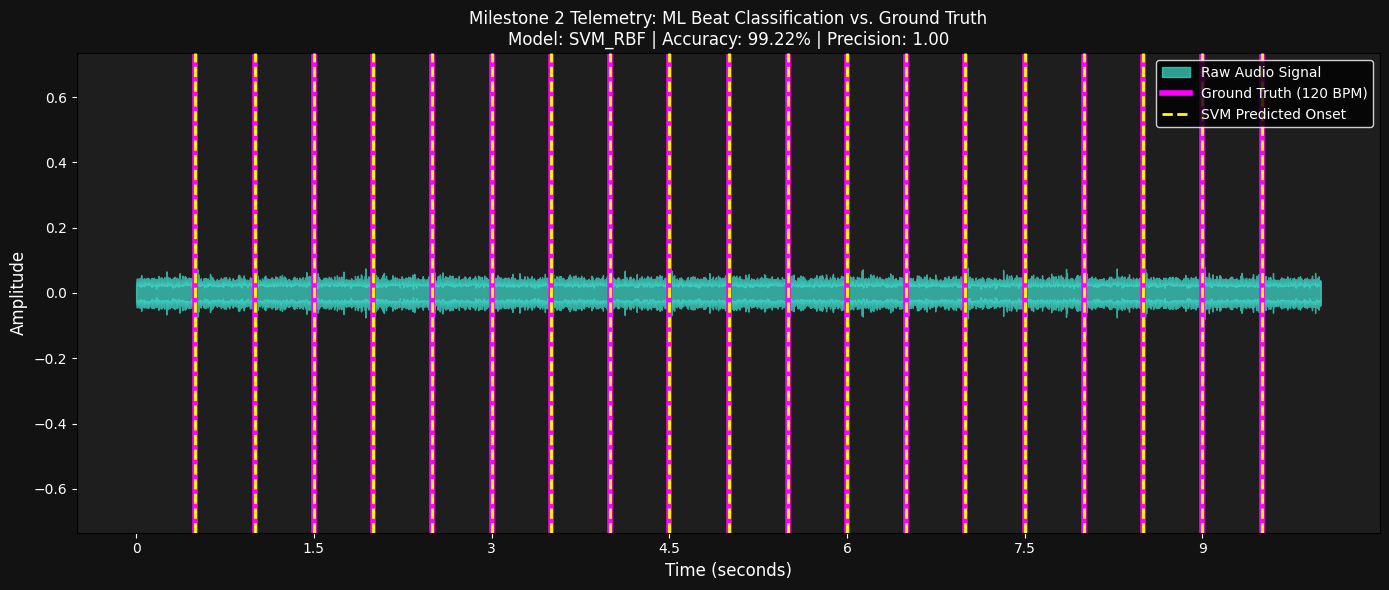

In [ ]:
# === CELL 5: RENDER BEAT DETECTION TELEMETRY PLOT ===
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(14, 6))

# Plot the raw mono audio waveform
librosa.display.waveshow(sig, sr=sr, alpha=0.7, color='turquoise', label='Raw Audio Signal', zorder=1)

# Overlay Ground Truth beats (Solid, bright magenta line)
for i, bt in enumerate(beats):
    plt.axvline(x=bt, color='magenta', linestyle='-', linewidth=4, zorder=2,
                label='Ground Truth (120 BPM)' if i == 0 else "")

# Overlay ML Predicted beats (Sharp, bright yellow line on top)
for i, pt in enumerate(ts):
    plt.axvline(x=pt, color='yellow', linestyle='--', linewidth=2, zorder=3,
                label='SVM Predicted Onset' if i == 0 else "")

# Formatting the chart
plt.title(f"Milestone 2 Telemetry: ML Beat Classification vs. Ground Truth\nModel: {res['best_model_name']} | Accuracy: {res['AD_acc']:.2f}% | Precision: {res['precision']:.2f}", fontsize=14, pad=15)
plt.xlabel("Time (seconds)", fontsize=12)
plt.ylabel("Amplitude", fontsize=12)

# Prevent duplicate labels in legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper right', facecolor='black', edgecolor='white', labelcolor='white')

# Apply a dark theme background to make the contrasting lines pop
plt.gca().set_facecolor('#1e1e1e')
plt.gcf().patch.set_facecolor('#121212')
plt.gca().tick_params(colors='white')
plt.gca().xaxis.label.set_color('white')
plt.gca().yaxis.label.set_color('white')
plt.title(plt.gca().get_title(), color='white')

plt.tight_layout()
plt.show()